In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torchmetrics import Accuracy, F1Score, AUROC, Precision, Recall
from HistoLib import pytorch_dataset, pytorch_model, pytorch_gradcam, utils


2026-03-04 19:35:49.086963: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
utils.dataset_description()

Total images 691
Total patients 45


,20x,40x,Total
aca_bd,57,46,103
aca_md,44,46,90
aca_pd,45,42,87
nor,85,66,151
scc_bd,50,49,99
scc_md,30,36,66
scc_pd,48,47,95
Total,359,332,691


## Get images

In [3]:
resolution = '20x'      # One of ['20x', '40x']

train_loader, val_loader, test_loader, class_names = pytorch_dataset.get_dataloaders(
    resolution=resolution,
    batch_size=8,
    image_scale=0.25, # Consistent with baseline
    reproducible=True # Use the splits from the original paper.
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

def show_batch(loader, title="Batch"):
    images, labels = next(iter(loader))
    plt.figure(figsize=(15, 6))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        # Denormalize
        img = images[i].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Class: {class_names[labels[i].item()]}")
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


Number of training batches: 33
Number of validation batches: 6
Number of test batches: 6


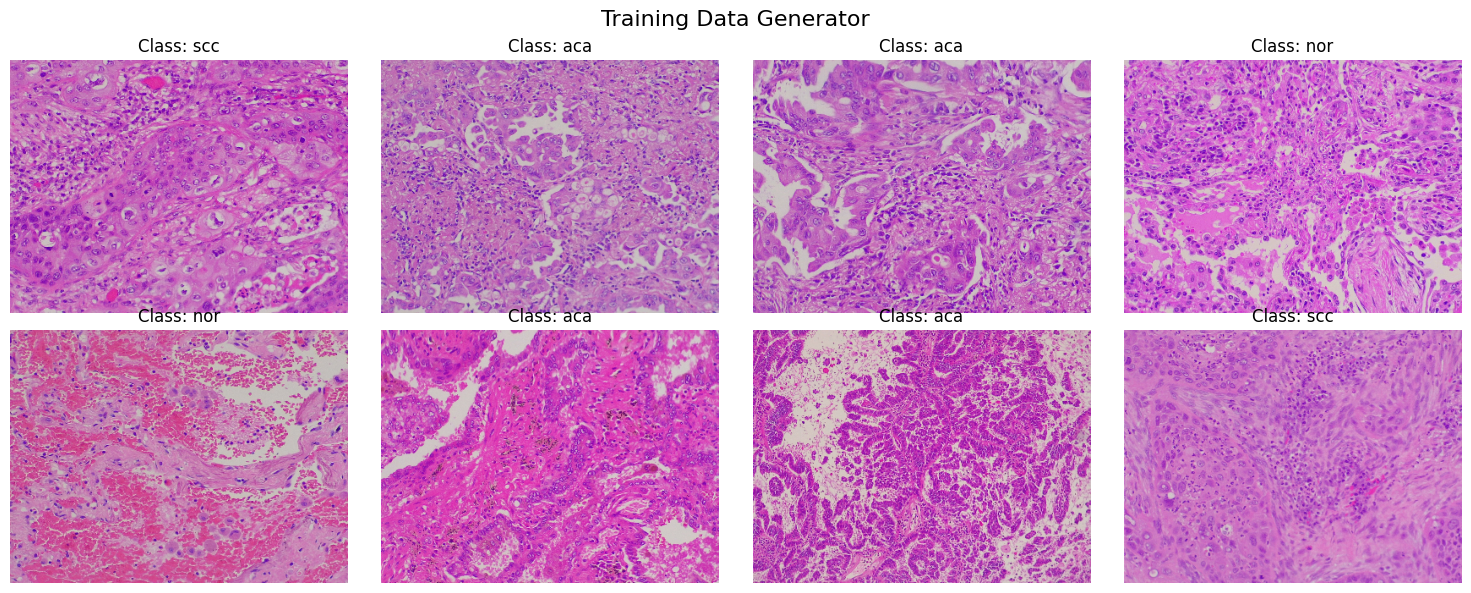

In [4]:
show_batch(train_loader, "Training Data Generator")


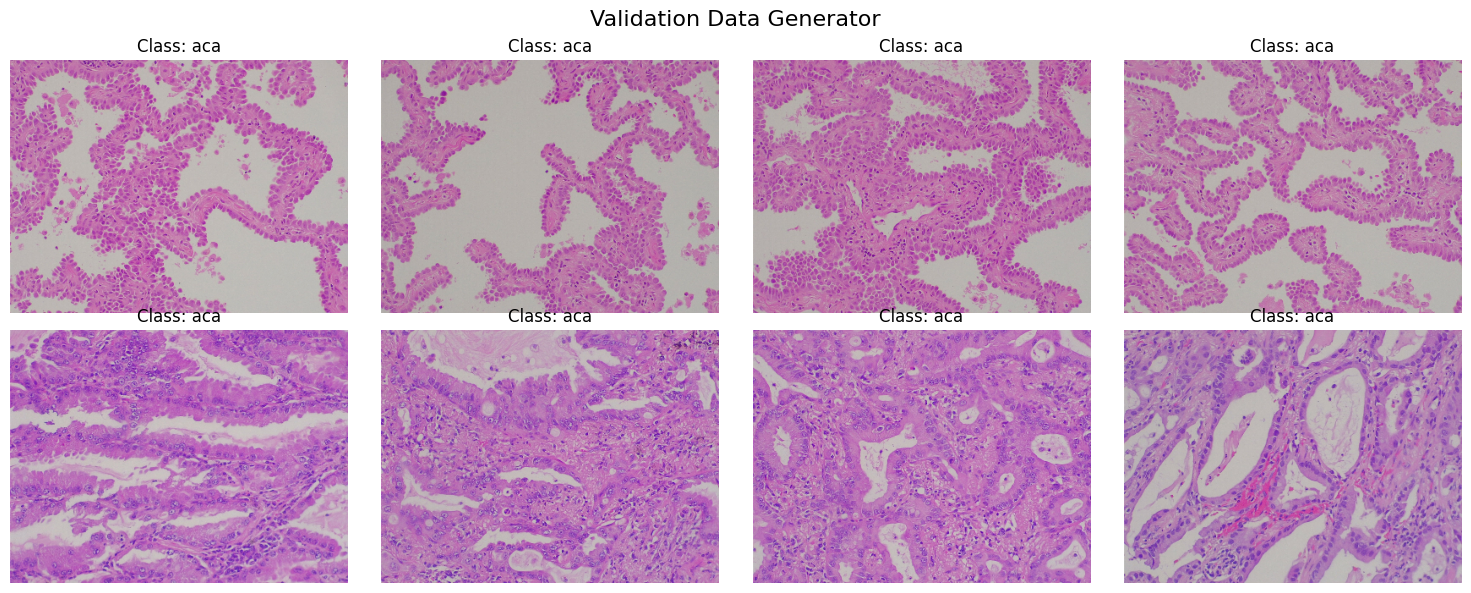

In [5]:
show_batch(val_loader, "Validation Data Generator")


## Train Model

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
num_classes = len(class_names)
model = pytorch_model.get_model(num_classes).to(device)


Using device: cuda


In [7]:
# Compute class weights
train_labels = train_loader.dataset.labels
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
weights = total_samples / (num_classes * class_counts)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)

metrics_collection = {
    'acc': Accuracy(task="multiclass", num_classes=num_classes).to(device),
    'f1': F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'auc': AUROC(task="multiclass", num_classes=num_classes).to(device),
    'precision': Precision(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'recall': Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
}

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

epochs = 50
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        pbar.set_postfix({'loss': loss.item()})
        
    train_loss = running_loss / len(train_loader)
    train_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    
    model.eval()
    val_running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            for m in metrics_collection.values(): m(outputs, labels)
            
    val_loss = val_running_loss / len(val_loader)
    val_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Acc: {train_metrics['acc']:.4f} - Val Loss: {val_loss:.4f}, Acc: {val_metrics['acc']:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'baseline_pytorch_best.pth')


Epoch 1/50 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


Epoch 1/50 - Train Loss: 1.0692, Acc: 0.4677 - Val Loss: 1.0034, Acc: 0.5625


Epoch 2/50 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 48/50 - Train Loss: 0.1330, Acc: 0.9468 - Val Loss: 0.2768, Acc: 0.8958


Epoch 49/50 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 49/50 - Train Loss: 0.1151, Acc: 0.9772 - Val Loss: 0.2509, Acc: 0.8542


Epoch 50/50 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 50/50 - Train Loss: 0.1331, Acc: 0.9696 - Val Loss: 0.2758, Acc: 0.8542


## Evaluate using test data

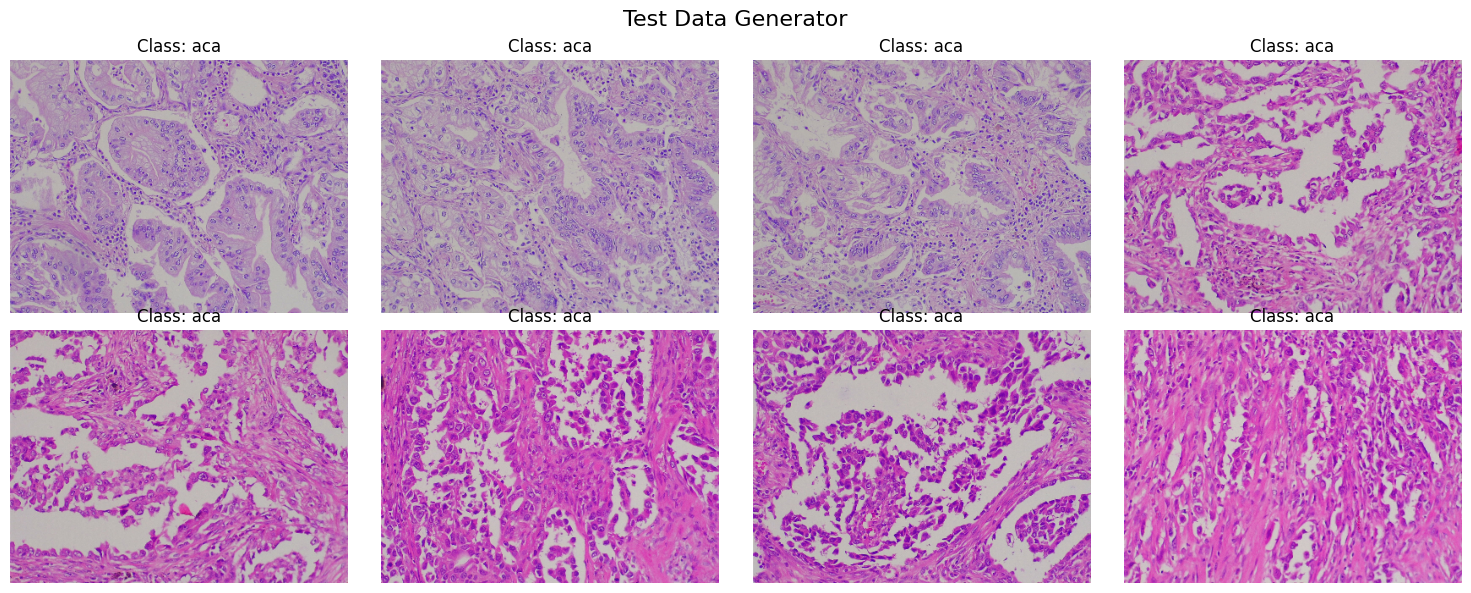

In [8]:
show_batch(test_loader, "Test Data Generator")


Test Loss: 0.1547
Test Accuracy: 0.9583
Test F1 Score: 0.9580
Test AUC: 0.9969
Test Precision (Macro): 0.9537
Test Recall (Macro): 0.9639


Evaluation metrics saved to 'evaluation_metrics.png'


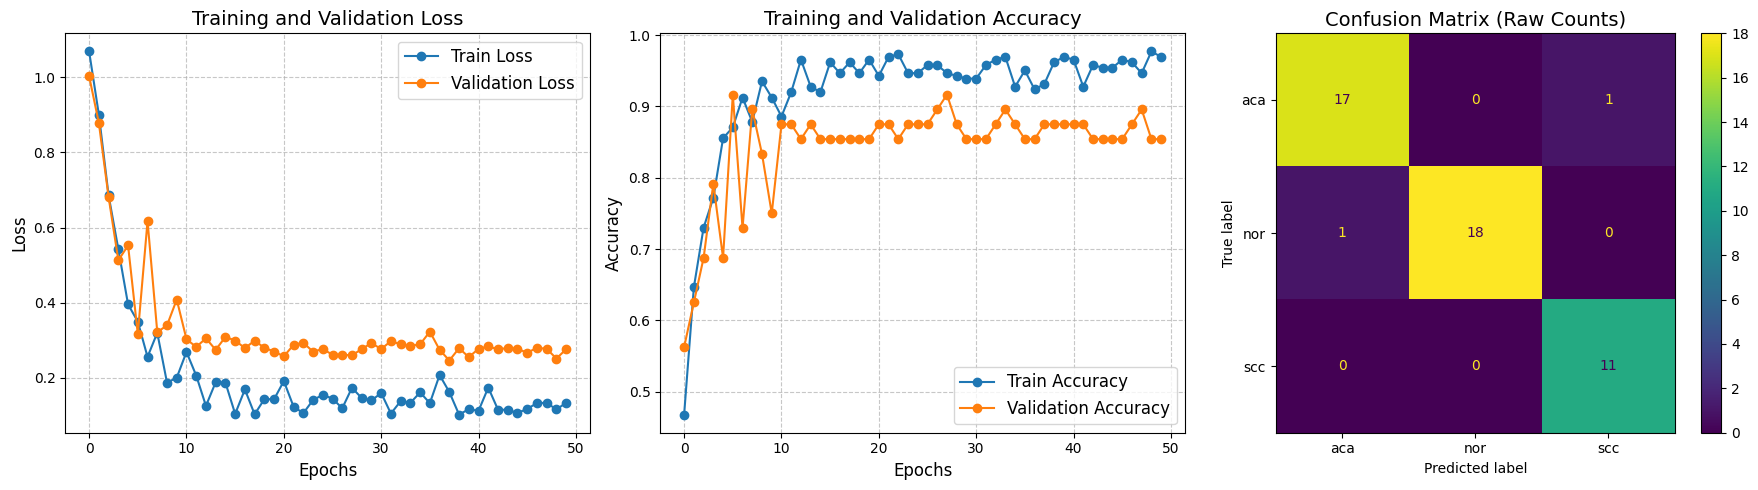

In [9]:
model.load_state_dict(torch.load('baseline_pytorch_best.pth'))
model.eval()
test_loss = 0.0
for m in metrics_collection.values(): m.reset()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['acc']:.4f}")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")
print(f"Test AUC: {test_metrics['auc']:.4f}")
print(f"Test Precision (Macro): {test_metrics['precision']:.4f}")
print(f"Test Recall (Macro): {test_metrics['recall']:.4f}")

from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Plot and save nicely formatted metrics
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot Loss
axs[0].plot(history['train_loss'], label='Train Loss', marker='o')
axs[0].plot(history['val_loss'], label='Validation Loss', marker='o')
axs[0].set_title('Training and Validation Loss', fontsize=14)
axs[0].set_xlabel('Epochs', fontsize=12)
axs[0].set_ylabel('Loss', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].legend(fontsize=12)

# Plot Accuracy
axs[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axs[1].plot(history['val_acc'], label='Validation Accuracy', marker='o')
axs[1].set_title('Training and Validation Accuracy', fontsize=14)
axs[1].set_xlabel('Epochs', fontsize=12)
axs[1].set_ylabel('Accuracy', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].legend(fontsize=12)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, normalize=None, ax=axs[2])
axs[2].set_title(f"Confusion Matrix (Raw Counts)", fontsize=14)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
print("Evaluation metrics saved to 'evaluation_metrics.png'")
plt.show()


Generating Grad-CAM samples...


Grad-CAM samples saved to gradcam_samples.png


Grad-CAM samples saved to 'gradcam_samples.png'


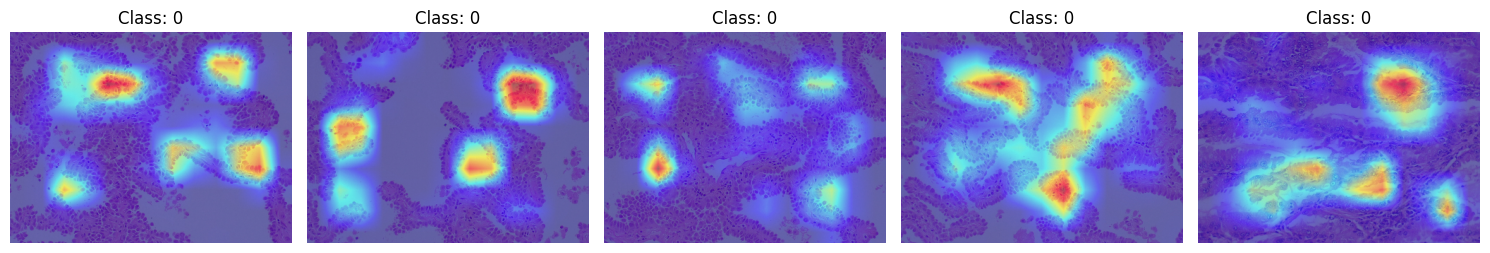

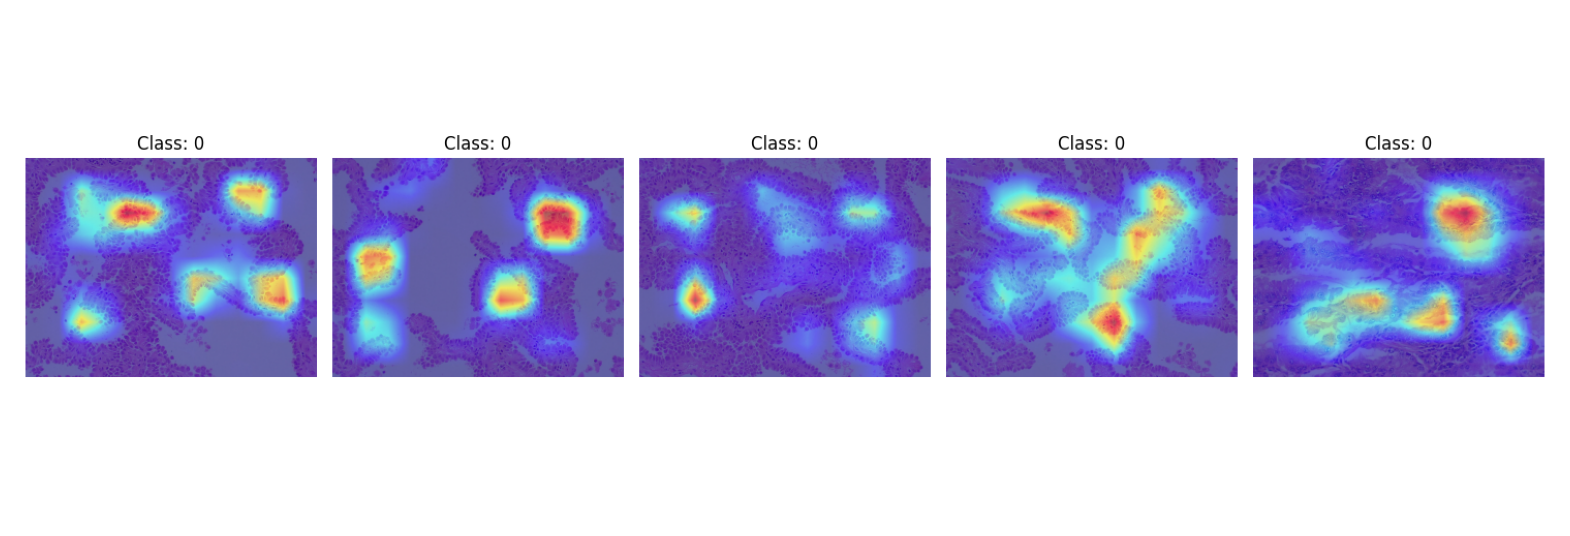

In [10]:
print("Generating Grad-CAM samples...")
model.eval()
pytorch_gradcam.generate_samples(
    model, 
    val_loader, 
    device, 
    num_samples=5, 
    output_path='gradcam_samples.png'
)
print("Grad-CAM samples saved to 'gradcam_samples.png'")
import matplotlib.image as mpimg
img = mpimg.imread('gradcam_samples.png')
plt.figure(figsize=(20, 10))
plt.imshow(img)
plt.axis('off')
plt.show()
